In [1]:
!pip install -q kaggle

In [2]:
!mkdir -p ~/.kaggle

In [3]:
token = "KGAT_95c9fdc845c39eab4981e6e152acf157"

with open("/root/.kaggle/access_token", "w") as f:
    f.write(token)

In [4]:
!chmod 600 ~/.kaggle/access_token

In [5]:
!kaggle datasets list -s intel

ref                                                                     title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
puneet6060/intel-image-classification                                   Intel Image Classification                           363152213  2019-01-30 09:22:58.647000         194958       1708  0.75             
zusmani/pakistanintellectualcapitalcs                                   Pakistan Intellectual Capital                           123389  2021-05-28 10:09:51.570000           3740        158  0.9705882        
mhassansaboor/intel-stock-data-1980-2024                                Intel Stock Data (1980-2024)                            288190  2024-12-25 16:12:36.507000      

In [6]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:05<00:00, 70.8MB/s]



In [7]:
!unzip intel-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

In [8]:
import os

In [9]:
os.listdir()

['.config',
 'intel-image-classification.zip',
 'seg_train',
 'seg_pred',
 'seg_test',
 'sample_data']

In [10]:
os.listdir("seg_train")

['seg_train']

In [11]:
os.listdir("seg_train")

['seg_train']

In [12]:
os.listdir("seg_train/seg_train")

['glacier', 'forest', 'mountain', 'buildings', 'street', 'sea']

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [51]:
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

In [52]:
train_dataset = ImageFolder("seg_train/seg_train",transform=transform)


In [53]:
train_dataset

Dataset ImageFolder
    Number of datapoints: 14034
    Root location: seg_train/seg_train
    StandardTransform
Transform: Compose(
               Resize(size=(150, 150), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [54]:
train_dataset[0]

(tensor([[[0.9686, 0.9686, 0.9725,  ..., 0.9725, 0.9686, 0.9686],
          [0.9647, 0.9686, 0.9686,  ..., 0.9725, 0.9686, 0.9686],
          [0.9647, 0.9647, 0.9686,  ..., 0.9725, 0.9686, 0.9686],
          ...,
          [0.1843, 0.2431, 0.1922,  ..., 0.2000, 0.1765, 0.3686],
          [0.3020, 0.1843, 0.1686,  ..., 0.0863, 0.2157, 0.1529],
          [0.2314, 0.2157, 0.2353,  ..., 0.1216, 0.2000, 0.2471]],
 
         [[0.9686, 0.9686, 0.9725,  ..., 0.9725, 0.9686, 0.9686],
          [0.9647, 0.9686, 0.9686,  ..., 0.9725, 0.9686, 0.9686],
          [0.9647, 0.9647, 0.9686,  ..., 0.9725, 0.9686, 0.9686],
          ...,
          [0.1804, 0.2392, 0.1882,  ..., 0.1804, 0.1569, 0.3490],
          [0.2980, 0.1804, 0.1647,  ..., 0.0667, 0.1961, 0.1333],
          [0.2275, 0.2118, 0.2314,  ..., 0.1020, 0.1804, 0.2275]],
 
         [[0.9608, 0.9608, 0.9647,  ..., 0.9725, 0.9608, 0.9608],
          [0.9569, 0.9608, 0.9608,  ..., 0.9725, 0.9608, 0.9608],
          [0.9569, 0.9569, 0.9608,  ...,

In [55]:
len(train_dataset)

14034

In [56]:
image, label = train_dataset[0]

print(type(image))
print(type(label))
print(label)

<class 'torch.Tensor'>
<class 'int'>
0


In [57]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [58]:
class CNN(nn.Module):


    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1
        )
        self.fc1 = nn.Linear(
    in_features=64 * 37 * 37,
    out_features=128
)
        self.fc2 = nn.Linear(in_features=128, out_features=6)


    def forward(self, x):

      x = self.conv1(x)
      x = self.relu(x)
      x = self.pool(x)

      x = self.conv2(x)
      x = self.relu(x)
      x = self.pool(x)

      x = x.flatten(start_dim=1)

      x = self.fc1(x)
      x = self.relu(x)
      x = self.fc2(x)
      return x




In [59]:
model = CNN()
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [60]:
for epoch in range(10):

    epoch_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/10, Loss = {epoch_loss / len(train_loader):.4f}")

Epoch 1/10, Loss = 1.0272
Epoch 2/10, Loss = 0.6408
Epoch 3/10, Loss = 0.4364
Epoch 4/10, Loss = 0.2560
Epoch 5/10, Loss = 0.1366
Epoch 6/10, Loss = 0.0669
Epoch 7/10, Loss = 0.0430
Epoch 8/10, Loss = 0.0410
Epoch 9/10, Loss = 0.0369
Epoch 10/10, Loss = 0.0484


In [62]:
torch.save(model.state_dict(), "cnn_intel.pth")

In [25]:
print(os.listdir())

['.config', 'intel-image-classification.zip', 'seg_train', 'seg_pred', 'seg_test', 'sample_data']


In [63]:
print(next(model.parameters()).device)

cpu


In [64]:
test_dataset = ImageFolder("seg_test/seg_test", transform=transform)

In [65]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [66]:
model.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        predicted = torch.argmax(outputs, dim=1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Loss: {test_loss / len(test_loader):.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")

Test Loss: 1.2299
Test Accuracy: 77.87%


In [61]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

In [67]:
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

In [68]:
print(train_dataset.classes)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [69]:
model = CNN()

model.load_state_dict(torch.load("cnn_intel.pth"))

model.eval()

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=87616, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)

In [70]:
image = Image.open("test.png").convert("RGB")

In [71]:
image_tensor = transform(image)

In [72]:
image_tensor = image_tensor.unsqueeze(0)

In [73]:
print(image_tensor.shape)

torch.Size([1, 3, 150, 150])


In [74]:
with torch.no_grad():

    outputs = model(image_tensor)

    predicted = torch.argmax(outputs, dim=1)

In [75]:
class_names = test_dataset.classes
predicted_class = class_names[predicted.item()]

print("Prediction:", predicted_class)

Prediction: sea


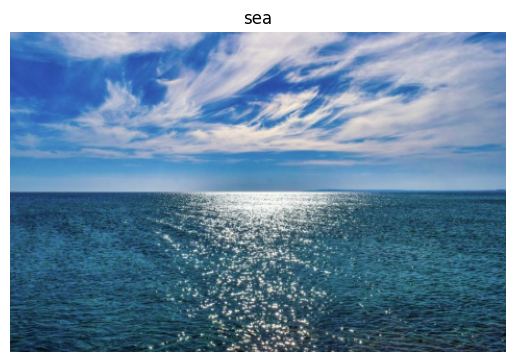

In [76]:
plt.imshow(image)
plt.title(f"{predicted_class}")
plt.axis("off")
plt.show()